# S&P 500 Equity+Options: Holdout Backtest

[`18_holdout_predictions`](18_holdout_predictions.ipynb) refit the selected
configuration and predicted 2021. This notebook runs the selected *strategy*
on those predictions - the same allocator, the same concentration, the same
risk overlay, the same costs - and reports what the portfolio would have
earned. It is the first number in this case study that was not produced on
data the selection could see.

**Learning objectives**

1. Hold a strategy specification fixed across two windows and change only the
   predictions it consumes.
2. Read a holdout result against the validation figure that selected it, and
   know what the gap between them does and does not establish.
3. Recognise which parts of a degradation are attributable to selection and
   which to the period.

**Book reference:** Chapter 20, Section 20.3.

**Prerequisites:** [`18_holdout_predictions`](18_holdout_predictions.ipynb).
Signals form after Friday's close and execute at the next available open. The
current-constituent universe retains survivorship bias, and it does so more
consequentially here than anywhere else in the case study: a 2021 window
evaluated on today's membership excludes every company that left the index,
so this number is optimistic by an amount this case study does not measure.

In [1]:
"""S&P 500 Equity+Options: run the selected strategy on the holdout predictions."""

import json
import sqlite3

import matplotlib.pyplot as plt
import polars as pl

from case_studies.research import Study, open_selection_field
from case_studies.research.holdout import build_holdout_training_spec
from case_studies.utils.backtest_loaders import (
    get_backtest_config,
    load_backtest_prices_for,
    warmup_periods_for,
)
from case_studies.utils.backtest_presets import (
    clone_backtest_spec,
    ensure_backtest_spec,
    strategy_view,
)
from case_studies.utils.backtest_runner import run_backtest
from case_studies.utils.notebook_contracts import prediction_members_in_force
from case_studies.utils.registry import (
    backtest_hash_from_parts,
    model_source,
    read_predictions,
    resolve_best_backtest_runs,
)
from case_studies.utils.registry.specs import training_hash_from_spec
from case_studies.utils.strategy_analysis import resolve_solvent_carrier
from case_studies.utils.uncertainty import load_daily_returns_with_timestamp
from utils.paths import get_case_study_dir
from utils.style import COLORS, FIGSIZE, add_message_title, show_with_alt

In [2]:
CASE_STUDY_ID = "sp500_equity_option_analytics"
LABEL = ""
MAX_SYMBOLS = 0

### What is asked for, and what it resolves to

The parameters above are the request; the values this notebook runs on are resolved here under
different names, so a resolved value cannot overwrite the request that produced it. An injected
parameter wins; otherwise the case study's own declaration does.

In [3]:
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
REGISTRY_DB = CASE_DIR / "run_log" / "registry.db"
bt_config = get_backtest_config(CASE_STUDY_ID)
# The label this stage runs under is a property of what the selection chose, so it is resolved
# below rather than here. `labels.primary` was the winner's label only by coincidence: the field
# spans every declared label, and the stages after the selection - price windows, schedule
# thinning, the return contract - have to be keyed to the label that won.
REQUESTED_LABEL = LABEL
print(f"Case study: {CASE_STUDY_ID}")

Case study: sp500_equity_option_analytics


In [4]:
_study = Study.at(CASE_DIR, case_study=CASE_STUDY_ID, entry_point="19_holdout_backtest")
CURRENT_MEMBERS, _population_notes = prediction_members_in_force(_study)
for _note in _population_notes:
    print(_note)

143 member(s) were dropped from the candidate pool for covering less than the cross-section their feature panels offered them: 0072f4cecd7e sp500_equity_option_analytics/fwd_ret_10d/validation deep_learning/nlinear: 125119 of 246641 declared (entity, session) pairs (50.7%) across 548 entities; of the 192139 its input panel offered it carries 125119 (65.1%) - 121522 missing; 0113aac277c5 sp500_equity_option_analytics/fwd_ret_risk_adj_5d/validation deep_learning/lstm_h64: 126458 of 248460 declared (entity, session) pairs (50.9%) across 549 entities; of the 194748 its input panel offered it carries 126458 (64.9%) - 122002 missing; 08446871beb5 sp500_equity_option_analytics/fwd_ret_5d/validation deep_learning/lstm_h64: 126478 of 249373 declared (entity, session) pairs (50.7%) across 550 entities; of the 194813 its input panel offered it carries 126478 (64.9%) - 122895 missing; 0932aea6185b sp500_equity_option_analytics/fwd_ret_5d/validation deep_learning/nlinear: 126478 of 249373 declared 

## 1. The strategy, read out of the frozen candidate set

[`16_risk_management`](16_risk_management.ipynb) freezes the field it ranked
over, and both this notebook and
[`18_holdout_predictions`](18_holdout_predictions.ipynb) read the selection out
of that set rather than re-deriving it. The set is immutable, so the two
resolve the same configuration without either being told what it is; handing
it over in a parameter or a file would add a way for them to disagree.

A holdout run that could be pointed at a strategy of the reader's choosing
would be a way to search the holdout. This one cannot be.

In [5]:
CANDIDATE_SET_NAME = f"{CASE_STUDY_ID}:holdout-candidates"
# The frozen set where it exists, and the same construction applied live where it does not.
# 16_risk_management writes it by opening the study, which canonical regeneration refuses
# wherever the generated directories are not symlinks - a reader's clean clone and the test
# fixtures both - so the set is in the published run log and absent everywhere else. Reading it
# is the stronger path: it is immutable, so it cannot follow an upstream change. Re-deriving is
# the same rule applied live, and cannot notice that something moved. Which one ran is printed.
#
# Both paths go through `open_selection_field`, which is also what 16 freezes with. They used to
# be separate copies and they disagreed: the freeze spanned every declared label and this
# fallback spanned one, so which configuration a reader selected depended on whether their
# registry held a `candidate_sets` table.
FIELD = open_selection_field(
    _study,
    case_study=CASE_STUDY_ID,
    name=CANDIDATE_SET_NAME,
    prediction_hashes=CURRENT_MEMBERS,
    resolve_best_backtest_runs=resolve_best_backtest_runs,
)
CANDIDATES = FIELD.candidate_set
FIELD_HASHES = list(FIELD.members)
FIELD_NAME = f"frozen candidate set {CANDIDATES.hash}" if CANDIDATES is not None else "live ranking"
SELECTION_SOURCE = FIELD.source
# The field says which backtests may be chosen from; the resolver says which one is chosen,
# and it is handed the field rather than the whole registry. `SelectionField.selected` is
# `CandidateSet.best_validation_sharpe`, which ranks the stored Sharpe column with a hash
# tie-break and applies nothing else - no re-ranking onto the timestamps every candidate
# prices, no label or universe restriction, no refusal of a run whose equity reached zero.
# This case study's field holds a conformal allocator that sits out its warm-up and books it
# as returns of exactly zero, so the two rankings read two different samples: they name the
# same backtest on this registry and value it at 2.6087 stored against 2.6329 over the shared
# sessions. `20_strategy_analysis` resolves the same way, so all three notebooks describe one
# configuration.
CARRIER = resolve_solvent_carrier(CASE_STUDY_ID, admitted=frozenset(FIELD_HASHES))
SELECTED = _study.results.open(CARRIER["val_backtest_hash"])
print(
    f"{FIELD_NAME}: {len(FIELD_HASHES)} members, resolver picks {SELECTED.hash}, "
    f"stored-Sharpe pick {FIELD.selected.hash}"
)

# The label the stages after the selection run under is the winner's, not the case study's
# primary. An injected LABEL is a request to run a different one, and it has to agree with what
# was selected or the holdout backtest would be keyed to a contract the selection does not name.
HOLDOUT_LABEL = CARRIER["label"]
if REQUESTED_LABEL and REQUESTED_LABEL != HOLDOUT_LABEL:
    raise RuntimeError(
        f"LABEL={REQUESTED_LABEL!r} was requested but the selection carried forward is "
        f"{SELECTED.hash} on {HOLDOUT_LABEL!r}. Running the holdout backtest under another "
        "label's contract would report a different strategy from the one selected."
    )
print(f"Label carried by the selection: {HOLDOUT_LABEL}")
print(f"Selection read from the {SELECTION_SOURCE}")

_why = SELECTED.completeness()
if _why is not None:
    raise RuntimeError(
        f"the selected validation backtest {SELECTED.hash} is incomplete: {_why}. "
        f"It was chosen from the {SELECTION_SOURCE}."
    )
CARRIER_SPEC = SELECTED.spec()
CARRIER_STRATEGY = strategy_view(CARRIER_SPEC)
carrier_record = SELECTED.registry_record()
CARRIER_PREDICTION_HASH = carrier_record["prediction_hash"]

with sqlite3.connect(REGISTRY_DB) as db:
    _carrier_source = db.execute(
        "SELECT t.family, t.config_name FROM prediction_sets p "
        "JOIN training_runs t USING(training_hash) WHERE p.prediction_hash = ?",
        (CARRIER_PREDICTION_HASH,),
    ).fetchone()
print(
    f"{FIELD_NAME} with {len(FIELD_HASHES)} members selects "
    f"{model_source(*_carrier_source)} with "
    f"{(CARRIER_STRATEGY.get('allocation') or {}).get('method', 'equal_weight')} allocation, "
    f"top-{(CARRIER_STRATEGY.get('signal') or {}).get('top_k')}, "
    + (
        f"risk overlay {(CARRIER_STRATEGY.get('risk') or {}).get('name')}"
        if (CARRIER_STRATEGY.get("risk") or {}).get("name")
        else "no risk overlay"
    )
)

frozen candidate set befcbfc67c7f: 3382 members, resolver picks c8212eda3bca, stored-Sharpe pick c8212eda3bca
Label carried by the selection: fwd_ret_risk_adj_5d
Selection read from the frozen candidate set befcbfc67c7f (3382 members)
frozen candidate set befcbfc67c7f with 3382 members selects gbm/default_mae with hrp allocation, top-5, risk overlay stop_loss_3pct


## 2. Which holdout prediction set belongs to this configuration

The holdout fit is a different training run from the validation fit by
construction - a different interval is a different computation - so the two
cannot be matched on a training hash, and matching on a family and
configuration name would accept a fit of the same model over the wrong window.

Rather than compare fields and hope the list is complete, this derives the
identity the selected configuration *should* have on the holdout, by the same
`build_holdout_training_spec` [`18_holdout_predictions`](18_holdout_predictions.ipynb)
fits, and requires a registered prediction under exactly that hash. The
derivation is deterministic and costs a dataset read rather than a fit, so the
two notebooks agree by construction: every boundary, the label buffer, the
feature floor, the fold identifier and the request metadata are all inside the
hash, and any of them differing makes it a different identity that this will
not accept.

In [6]:
with sqlite3.connect(REGISTRY_DB) as db:
    carrier_training_hash = db.execute(
        "SELECT training_hash FROM prediction_sets WHERE prediction_hash = ?",
        (CARRIER_PREDICTION_HASH,),
    ).fetchone()[0]
    VALIDATION_SPEC = json.loads(
        db.execute(
            "SELECT spec_json FROM training_runs WHERE training_hash = ?",
            (carrier_training_hash,),
        ).fetchone()[0]
    )
    carrier_checkpoint = db.execute(
        "SELECT checkpoint_kind, checkpoint_value FROM prediction_sets WHERE prediction_hash = ?",
        (CARRIER_PREDICTION_HASH,),
    ).fetchone()
    holdout_rows = db.execute(
        "SELECT p.prediction_hash, p.training_hash, p.checkpoint_kind, p.checkpoint_value "
        "FROM prediction_sets p WHERE p.split = 'holdout'"
    ).fetchall()

In [7]:
OBSERVATIONS = (
    pl.read_parquet(_study.root / "labels" / f"{VALIDATION_SPEC['label']}.parquet")
    .get_column("timestamp")
    .unique()
    .sort()
    .to_list()
)
EXPECTED_HOLDOUT_SPEC = build_holdout_training_spec(
    _study, VALIDATION_SPEC, timeline=OBSERVATIONS, case_study=CASE_STUDY_ID
)
EXPECTED_HOLDOUT_TRAINING = training_hash_from_spec(EXPECTED_HOLDOUT_SPEC)
_expected_fold = EXPECTED_HOLDOUT_SPEC["computation"]["cv"]["folds"][0]
print(
    f"The selected configuration's holdout fit is {EXPECTED_HOLDOUT_TRAINING}: "
    f"train {str(_expected_fold['train_start'])[:10]} to {str(_expected_fold['train_end'])[:10]}, "
    f"evaluate {str(_expected_fold['val_start'])[:10]} to {str(_expected_fold['val_end'])[:10]}"
)

matches = [row for row in holdout_rows if row[1] == EXPECTED_HOLDOUT_TRAINING]
if not matches:
    raise RuntimeError(
        f"no holdout prediction is registered under {EXPECTED_HOLDOUT_TRAINING}, the identity "
        f"this configuration's configuration derives. Run 18_holdout_predictions. The registry holds "
        + (
            ", ".join(f"{row[0]} (training {row[1]})" for row in holdout_rows)
            if holdout_rows
            else "no holdout predictions at all"
        )
    )
if len(matches) > 1:
    raise RuntimeError(
        f"{len(matches)} holdout predictions share training {EXPECTED_HOLDOUT_TRAINING}: "
        + ", ".join(row[0] for row in matches)
        + ". A holdout fit publishes exactly the selected checkpoint, so this registry carries "
        "rows from an older rule."
    )

HOLDOUT_PREDICTION_HASH, HOLDOUT_TRAINING_HASH, holdout_kind, holdout_value = matches[0]
if (holdout_kind, holdout_value) != carrier_checkpoint:
    raise RuntimeError(
        f"the holdout prediction is at {holdout_kind}={holdout_value} but the selection was made "
        f"on {carrier_checkpoint[0]}={carrier_checkpoint[1]}"
    )
print(
    f"Holdout prediction {HOLDOUT_PREDICTION_HASH} from training {HOLDOUT_TRAINING_HASH}, "
    f"the validation configuration {carrier_training_hash} refitted over the holdout interval "
    f"at {holdout_kind}={holdout_value}"
)

The selected configuration's holdout fit is 20dcd7aa0224: train 2017-02-01 to 2020-12-16, evaluate 2021-01-01 to 2021-12-31
Holdout prediction 79c65b6dda2f from training 20dcd7aa0224, the validation configuration df08239c4198 refitted over the holdout interval at iteration=350


The two windows the two fits saw, side by side. The gap between the training
end and the holdout open is one label buffer, which is what stops the last
training label's five-day outcome from resolving inside the window being
judged.

In [8]:
with sqlite3.connect(REGISTRY_DB) as db:
    holdout_spec = json.loads(
        db.execute(
            "SELECT spec_json FROM training_runs WHERE training_hash = ?",
            (HOLDOUT_TRAINING_HASH,),
        ).fetchone()[0]
    )
holdout_fold = holdout_spec["computation"]["cv"]["folds"][0]
validation_folds = VALIDATION_SPEC["computation"]["cv"]["folds"]

pl.DataFrame(
    [
        {
            "fit": "validation",
            "folds": len(validation_folds),
            "train from": min(str(f["train_start"])[:10] for f in validation_folds),
            "train to": max(str(f["train_end"])[:10] for f in validation_folds),
            "evaluated": f"{min(str(f['val_start'])[:10] for f in validation_folds)}"
            f" to {max(str(f['val_end'])[:10] for f in validation_folds)}",
        },
        {
            "fit": "holdout",
            "folds": 1,
            "train from": str(holdout_fold["train_start"])[:10],
            "train to": str(holdout_fold["train_end"])[:10],
            "evaluated": f"{str(holdout_fold['val_start'])[:10]}"
            f" to {str(holdout_fold['val_end'])[:10]}",
        },
    ]
)

fit,folds,train from,train to,evaluated
str,i64,str,str,str
"""validation""",2,"""2017-02-01""","""2019-12-26""","""2019-01-07 to 2020-12-23"""
"""holdout""",1,"""2017-02-01""","""2020-12-16""","""2021-01-01 to 2021-12-31"""


## 3. Run the selected strategy on the holdout window

The specification is the selected configuration's own, cloned and re-pointed at the holdout
predictions. Nothing about the strategy is re-derived here: re-deriving it
would let a change anywhere upstream alter what the holdout evaluates without
the change being visible as a different selection.

Prices are loaded for the holdout window with the allocator's warmup prefix.
The covariance estimator this configuration uses needs history before its first
rebalance, and without the prefix it would fall back to an imputed warmup on
exactly the dates the result is read from.

In [9]:
prices = load_backtest_prices_for(
    CASE_STUDY_ID,
    HOLDOUT_LABEL,
    split="holdout",
    warmup_periods=warmup_periods_for(CASE_STUDY_ID),
    max_symbols=MAX_SYMBOLS,
)
print(
    f"Price support: {len(prices):,} rows across {prices['symbol'].n_unique()} symbols, "
    f"{prices['timestamp'].min()} to {prices['timestamp'].max()}"
)
predictions = read_predictions(CASE_STUDY_ID, HOLDOUT_PREDICTION_HASH)
print(
    f"Predictions: {predictions.height:,} rows over {predictions['timestamp'].n_unique()} sessions"
)

Price support: 434,220 rows across 591 symbols, 2018-08-03 00:00:00 to 2021-12-31 00:00:00
Predictions: 94,991 rows over 247 sessions


In [10]:
holdout_strategy_spec = clone_backtest_spec(
    ensure_backtest_spec(
        CASE_STUDY_ID,
        bt_config,
        CARRIER_SPEC,
        prices=prices,
        prediction_hash=HOLDOUT_PREDICTION_HASH,
        initial_cash=bt_config.initial_cash,
    )
)
HOLDOUT_BACKTEST_HASH = backtest_hash_from_parts(HOLDOUT_PREDICTION_HASH, holdout_strategy_spec)

# The whole backtest specification, not the strategy block. `strategy_view` returns signal,
# allocation and risk and stops there, so a check built on it would pass a holdout run at
# different commissions, slippage, fill timing or stop behaviour - and holding those fixed is
# most of what makes the holdout number comparable to the validation one. What legitimately
# differs between the two runs is the predictions consumed and the price panel sliced to, so
# only those are projected out.
BACKTEST_VARYING_PATHS = (
    ("_runtime_backtest_config",),
    ("input_identity",),
    ("backtest_config", "metadata", "prediction_hash"),
    ("backtest_config", "metadata", "preset_path"),
)


def _without(value, path: tuple[str, ...]):
    """``value`` with ``path`` removed, leaving every sibling in place."""
    if not isinstance(value, dict) or path[0] not in value:
        return value
    pruned = dict(value)
    if len(path) == 1:
        pruned.pop(path[0])
    else:
        pruned[path[0]] = _without(pruned[path[0]], path[1:])
    return pruned


def _comparable_backtest(spec: dict) -> dict:
    projected = spec
    for path in BACKTEST_VARYING_PATHS:
        projected = _without(projected, path)
    return projected


carried = _comparable_backtest(holdout_strategy_spec)
validation_carried = _comparable_backtest(CARRIER_SPEC)
if carried != validation_carried:
    moved = sorted(
        key
        for key in set(carried) | set(validation_carried)
        if carried.get(key) != validation_carried.get(key)
    )
    raise RuntimeError(f"the holdout strategy differs from the selected one in {moved}")
print(f"Holdout backtest identity {HOLDOUT_BACKTEST_HASH}")

Holdout backtest identity 4669b810fc64


In [11]:
with sqlite3.connect(REGISTRY_DB) as db:
    already = db.execute(
        "SELECT stage FROM backtest_runs WHERE backtest_hash = ?", (HOLDOUT_BACKTEST_HASH,)
    ).fetchone()
if already is None:
    result = run_backtest(
        CASE_STUDY_ID,
        HOLDOUT_PREDICTION_HASH,
        holdout_strategy_spec,
        prices=prices,
        predictions=predictions,
        label=HOLDOUT_LABEL,
        register=True,
        initial_cash=bt_config.initial_cash,
        calendar=bt_config.calendar,
    )
    print(
        f"Ran: Sharpe={result.metrics['sharpe']:.3f}, "
        f"max drawdown={result.metrics['max_drawdown']:.1%}"
    )
else:
    print(f"Already registered under stage {already[0]!r}; read, not re-run")

with sqlite3.connect(REGISTRY_DB) as db:
    registered_stage = db.execute(
        "SELECT stage FROM backtest_runs WHERE backtest_hash = ?", (HOLDOUT_BACKTEST_HASH,)
    ).fetchone()
if registered_stage is None:
    raise RuntimeError("the holdout backtest did not register")
if registered_stage[0] != "holdout":
    raise RuntimeError(
        f"the holdout backtest registered under stage {registered_stage[0]!r}; the stage is "
        "inferred from the prediction's split, so this row is not reachable as holdout evidence"
    )

Already registered under stage 'holdout'; read, not re-run


## 4. What the holdout says

The two rows below are the same strategy on two windows. Both are read from
`backtest_metrics`, so each is measured over the span its own run priced. The
validation row is therefore the registered run's own figure and not the number the
selection was decided on: the field here holds a conformal allocator that sits out
its warm-up and books it as returns of exactly zero, so the ranking re-measures every
candidate over the sessions they all price. That figure is printed above the table,
and on this registry the two differ - 2.6329 over the shared sessions against 2.6087
stored.

Either way the validation figure is optimistic by construction: it is the maximum of
a search, and the maximum of a search is a biased estimate of the thing searched over.
The holdout figure has no such bias from *this* case study's selection.

It carries a different one. The window is a single year, and 2021 was a
particular year - a broad advance in US equities - so a result this good in a
year like that is weaker evidence than the same result across a decade. One
window cannot separate a strategy that works from a strategy that suits the
window it was tested on, and nothing downstream of here can either.

In [12]:
# The metric the configuration was actually selected on, stated before the table so the
# validation row below is read as what it is - the registered run over its own span.
print(
    f"selected on Sharpe={CARRIER['val_sharpe']:.4f} over the "
    f"{CARRIER['comparison_n_periods'] or 'full'} sessions every candidate prices"
)

with sqlite3.connect(REGISTRY_DB) as db:
    comparison = pl.read_database(
        """
        SELECT b.backtest_hash, b.stage, m.sharpe, m.total_return, m.max_drawdown,
               m.volatility, m.num_trades, m.n_periods,
               m.sharpe_ci95_lo, m.sharpe_ci95_hi
        FROM backtest_runs b JOIN backtest_metrics m USING(backtest_hash)
        WHERE b.backtest_hash IN (?, ?)
        """,
        connection=db,
        execute_options={"parameters": [HOLDOUT_BACKTEST_HASH, SELECTED.hash]},
    )
if comparison.height != 2:
    raise RuntimeError("one of the two backtests has no registered metrics")

comparison = comparison.with_columns(
    pl.when(pl.col("backtest_hash") == HOLDOUT_BACKTEST_HASH)
    .then(pl.lit("holdout (2021)"))
    .otherwise(pl.lit("validation (registered span)"))
    .alias("window")
).sort("window")
comparison.select(
    "window",
    "sharpe",
    "sharpe_ci95_lo",
    "sharpe_ci95_hi",
    "total_return",
    "max_drawdown",
    "volatility",
    "num_trades",
    "n_periods",
)

selected on Sharpe=2.6329 over the 492 sessions every candidate prices


window,sharpe,sharpe_ci95_lo,sharpe_ci95_hi,total_return,max_drawdown,volatility,num_trades,n_periods
str,f64,f64,f64,f64,f64,f64,f64,f64
"""holdout (2021)""",1.316705,-0.429554,3.055807,0.170145,-0.072219,0.125299,232.0,252.0
"""validation (registered span)""",2.608738,1.356914,3.876558,1.846407,-0.137982,0.212023,485.0,497.0


The Sharpe intervals are the part to read first, and what they support is
narrower than it looks.

Each interval describes uncertainty in *its own* estimate. The holdout's says
how much a single year of this strategy's weekly rebalances pins down its
Sharpe; where it spans zero, that year does not establish that the strategy
earns anything at all. The validation interval says the same for the
development window, and carries the additional problem that its point estimate
is the maximum of a search and is optimistic by an amount neither interval
measures.

What neither interval gives is a test of the *difference* between the two
windows. That would need an interval for the gap itself, and the two are
measured over disjoint periods on different numbers of observations, so it
cannot be read off by asking whether one point estimate falls inside the
other's interval. The cells below therefore report both intervals and the
arithmetic difference, and stop there. Attributing the difference - to
selection bias, to a different market, or to both - is not something one
holdout year can do, and no notebook downstream of this one can either.

In [13]:
_holdout = comparison.filter(pl.col("window") == "holdout (2021)").row(0, named=True)
_validation = comparison.filter(pl.col("window") == "validation (registered span)").row(
    0, named=True
)
_spans_zero = _holdout["sharpe_ci95_lo"] <= 0.0 <= _holdout["sharpe_ci95_hi"]
print(
    f"Validation Sharpe {_validation['sharpe']:.3f} over the registered span "
    f"[{_validation['sharpe_ci95_lo']:.3f}, {_validation['sharpe_ci95_hi']:.3f}] "
    f"over {int(_validation['n_periods'])} sessions"
)
print(
    f"Holdout Sharpe {_holdout['sharpe']:.3f} "
    f"[{_holdout['sharpe_ci95_lo']:.3f}, {_holdout['sharpe_ci95_hi']:.3f}] "
    f"over {int(_holdout['n_periods'])} sessions"
)
print(f"Arithmetic difference {_holdout['sharpe'] - _validation['sharpe']:+.3f}, untested")
print(
    "The holdout interval "
    + (
        "spans zero, so this year does not establish that the strategy earns anything"
        if _spans_zero
        else "excludes zero, so this year places its Sharpe away from zero"
    )
)

Validation Sharpe 2.609 over the registered span [1.357, 3.877] over 497 sessions
Holdout Sharpe 1.317 [-0.430, 3.056] over 252 sessions
Arithmetic difference -1.292, untested
The holdout interval spans zero, so this year does not establish that the strategy earns anything


The holdout equity path, drawn on its own axis. It is one year at weekly
rebalances, so the shape carries far less information than the same picture
over the validation window and is shown to make the drawdown legible rather
than to support a claim.

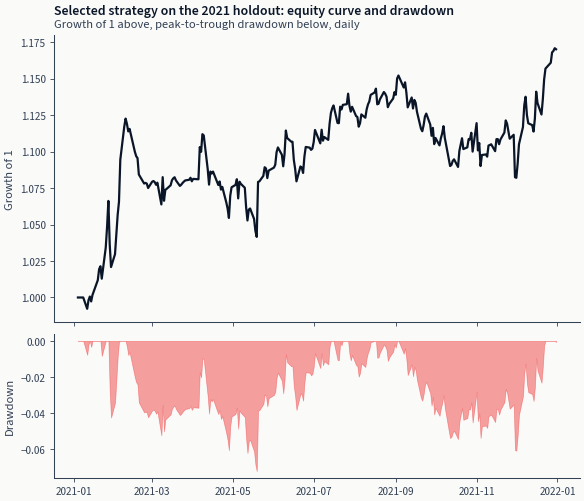

In [14]:
holdout_returns = load_daily_returns_with_timestamp(CASE_STUDY_ID, HOLDOUT_BACKTEST_HASH)
if holdout_returns is None or holdout_returns.is_empty():
    raise RuntimeError("the holdout backtest registered no daily return series")

curve = holdout_returns.sort("timestamp").with_columns(
    ((1.0 + pl.col("ret")).cum_prod()).alias("equity")
)
curve = curve.with_columns((pl.col("equity") / pl.col("equity").cum_max() - 1.0).alias("drawdown"))

fig, (ax_equity, ax_dd) = plt.subplots(
    2,
    1,
    figsize=FIGSIZE["dual_v"],
    sharex=True,
    height_ratios=[2, 1],
    constrained_layout=True,
)
ax_equity.plot(curve["timestamp"], curve["equity"], color=COLORS["blue"], linewidth=1.6)
ax_equity.set_ylabel("Growth of 1")
ax_dd.fill_between(curve["timestamp"], curve["drawdown"], 0.0, color=COLORS["negative"], alpha=0.5)
ax_dd.set_ylabel("Drawdown")
add_message_title(
    ax_equity,
    "Selected strategy on the 2021 holdout: equity curve and drawdown",
    "Growth of 1 above, peak-to-trough drawdown below, daily",
)
show_with_alt(
    fig,
    "Two panels sharing a date axis over the holdout year: growth of one unit of capital above, "
    "and peak-to-trough drawdown filled below.",
)

## Key takeaways

1. The strategy run here is the selected configuration's own specification, cloned and
   re-pointed at the holdout predictions. Nothing about it was re-derived, so
   a change upstream would show up as a different selection rather than as a
   quietly different holdout.
2. The holdout prediction set is matched to the selected configuration by comparing the two
   training specifications field by field, because a holdout refit is a
   different training identity and cannot be matched on a hash.
3. A validation figure is the maximum of a search and is optimistic. A single
   holdout year is unbiased with respect to that search and is noisy, and the
   registered Sharpe interval is what says how noisy. Neither interval is a
   test of the difference between the two, which is why none is reported.
4. A drop from validation to holdout has at least two sufficient explanations
   - selection bias and a different market - and one window cannot separate
   them. Neither can any notebook downstream of this one.
5. Survivorship bias bites hardest here. The universe is today's S&P 500
   membership, so the 2021 window is evaluated on companies known to have
   stayed in the index.

**Next:** [`20_strategy_analysis`](20_strategy_analysis.ipynb) assembles what
the case study has established across all of its stages, and states which of
its claims this window supports.